# Catalyst parameter calibration template

## Abstract

This manuscript intend to illustrate the procedure of calibrating the chemical dissolution parameters. The execution time of this example will be around 80 minutes, which 

can be saved by reducing the number of trials of the optimizer

In [1]:
# Importing the necessary libraries
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.integrate import solve_ivp, trapezoid
import warnings
warnings.filterwarnings("ignore")

## defining the kinetic equations

### Global parameters
These parameters are constant that won't change anywhere

In [2]:
F = 96485  # C. mol-1. It is the Faraday constant.
R = 8.314  # J. mol-1.K-1. It is the universal gas constant.
rho_H2O = 997  # (kg/m3)
M_H2O = 18.02e-3  # kg/mol
alpha_4 = 0.5
rho_cc = 2.26 
Mcc = 12.01 
Ueq_4 = 0.2
Vm_Pt = 9.09  # Molar volume of Pt cm3/mol
M_Pt = 195.0849  # Molar mass of platinum (g/mol)
Cpt2_ref = 1e-3
rho_Pt = 21.45  # Density of platinum g/cm^3
GAMMA_max = 2.18e-9 # GAMMA(strong assumption): The active site quantity in moles per platinum area (mole/cm^2)

def Cproton_CCL(lambda_w, EW=1.1, rho_mem=0.002):
    return 1 / ((EW / rho_mem) + lambda_w * (M_H2O / rho_H2O))

### Kinetic equations

R1: PtDissolution()

R2: PtOxidation()

R3: PtOxideDissolution()

R4: PtDetachment()

In [3]:
def PtDissolution(Ucell, Tccl,  theta, Cpt2, k1, k1_ref, **kwarg):

    alpha_1 = 0.5
    Ueq_1 = 1.15  # Standard equilibrium potential Ueq_1
    n = 2  # Electron transferred
    # Modelled as Butler-Volmer equation
    Rf = np.exp((alpha_1 * F * n) / (R * Tccl) * (Ucell - Ueq_1))  # Forward
    Rb = Cpt2 / Cpt2_ref * np.exp((-(1 - alpha_1) * F * n) / (R * Tccl) * (Ucell - Ueq_1))  # Reverse
    return k1 * (1 - theta) * Rf - k1_ref * Rb

def PtOxidation(Ucell, Tccl, Ch, theta, k2, k2_ref, **kwarg):

    # Standard equilibrium potential Ueq_2
    Ueq_2 = 0.97
    n = 2
    alpha_2 = 0.5
    omega = 27e3
    Ch_ref = 1e-3

    Rf = (k2 * np.exp(-omega * theta / (R * Tccl)) *
          np.exp((alpha_2 * F * n) / (R * Tccl) * (Ucell - Ueq_2)))
    Rb = (k2_ref * theta * (Ch / Ch_ref) ** 2 *
          np.exp((-alpha_2 * F * n) / (R * Tccl) * (Ucell - Ueq_2)))

    return Rf - Rb

def PtOxideDissolution(theta, Ch, k3, **kwarg):

    return k3 * theta * Ch ** 2

def PtDetachment(Ucell, Tccl, r, k4_ref, **kwarg):

    n = 2
    return k4_ref * Mcc / rho_cc * np.exp((alpha_4 * F * n) / (R * Tccl) * (Ucell - Ueq_4)) / r

## Setup the simulation

### Eletrocde material parameters

These parameters are related to the particle groups initialization

In [4]:
n_group_ptParticle = 50
rmin = 1e-8
rmax = 1e-6
dr = 1e-6 / n_group_ptParticle
r_m = (np.linspace(rmin, rmax, n_group_ptParticle + 1) + dr / 2)[1:]

In [5]:
def initPRD(resolution=100, rmin=1e-8, rmax=1e-6, std=0.549, mu=0.538):
    
    radius = np.linspace(rmin, rmax, resolution)
    pdf = 1/(std*np.sqrt(4*np.pi)) * np.exp(-(np.log(radius*1e7)-mu)**2/(std**2*2))
    return pdf

Text(0, 0.5, 'Density')

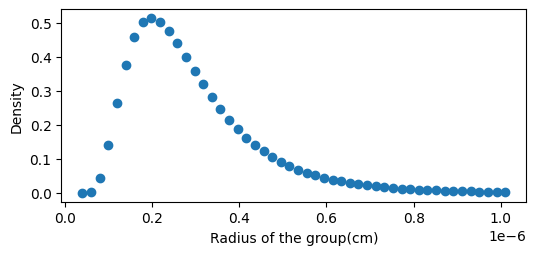

In [6]:
plt.figure(figsize=(6,2.5))
plt.scatter(r_m,initPRD(50))
plt.xlabel("Radius of the group(cm)")
plt.ylabel("Density")

## AST protocol

In [7]:
def ucell_sw(t):
    
    t = t%6
    t_stop = 6
    iload_rise =  0.2 * np.tanh(8*(t - t_stop / 4)) + 0.3
    iload_drop =  -0.2 * np.tanh(8*(t - t_stop * 3 / 4)) +0.3
    return iload_rise  + iload_drop

# def ucell_tw(t):
    
#     t = t%6
#     UPL = 0.95
#     LPL = 0.60
#     v_scan = 0.125
#     u = (UPL-LPL)/np.pi*np.arcsin(np.sin((np.pi*v_scan)/(UPL-LPL)*t-np.pi/2))+(UPL-LPL)/2+LPL
#     return u

Text(0, 0.5, 'Ucell')

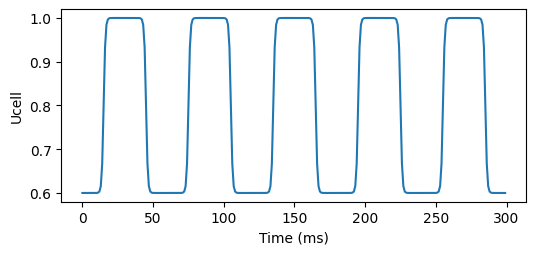

In [8]:
fig, ax = plt.subplots(figsize=(6,2.5))
ax.plot(ucell_sw(np.arange(0,30,0.1)))
ax.set_xlabel("Time (ms)")
ax.set_ylabel("Ucell")

## Defining the CCL class that represent the Pt loading



In [9]:
class ccl():
    
    def __init__(self):
        
        self.Ucell = ucell_sw
        self.Tfc = 353.15
        self.parameters = {"krdp": 1e-10, "k1":3e-9, "k1_ref":1e-18, "k2": 1e-13, "k2_ref": 1e-13, "k3": 1e-15, "k4": 0, "k5":0, "k4_ref":1.7e-21}
        self.prd0 = initPRD(resolution=n_group_ptParticle)
        
    def dxdt(self, t, x):
            
        C_Pt2_ccl = x[0]
        theta_CCL = x[1:1+len(r_m)]
        prd = x[-len(r_m):]
        u = self.Ucell(t)
        
        # CCL kinetic
        # 0.043 + 17.81*0.85 - 39.85*0.85**2 + 36*0.85**3 = 8.5
        R0 = (2*9.09*0.2e-4)/(R*353)
        C_H_CCL = Cproton_CCL(lambda_w=8.5)
        kdis = PtDissolution(u, self.Tfc, C_Pt2_ccl, theta_CCL, **self.parameters)
        kox = PtOxidation(u, self.Tfc, C_H_CCL, theta_CCL, **self.parameters)
        kcdis = PtOxideDissolution(theta_CCL, C_H_CCL, **self.parameters)
        kdet = PtDetachment(u, self.Tfc, r_m, **self.parameters)
        drdt = Vm_Pt * self.parameters["krdp"] * C_Pt2_ccl * np.exp(-R0 / r_m) - Vm_Pt * (kdis + kox) * Cpt2_ref * np.exp(R0 / r_m)
        M_Pt0 = 4 / 3 * np.pi * rho_Pt * trapezoid(y=self.prd0 * r_m ** 3, x=r_m)
        dMdisdt = 4 * np.pi * rho_Pt * trapezoid(y=prd * r_m ** 2 * drdt, x=r_m)
        dMcdisdt = 4 * np.pi * rho_Pt * trapezoid(y=prd * r_m ** 2 * kcdis, x=r_m)
        dC_Pt2_ccl = -3.33 / M_Pt * (dMdisdt - dMcdisdt) / M_Pt0
        dfdt = -np.gradient(prd * drdt, r_m) - kdet * prd
        dthetadt = (((kox - kcdis) / GAMMA_max) - (2 * theta_CCL / r_m) * drdt)
        
        dxdt = [0]*(1+len(r_m)*2)
        dxdt[0] = dC_Pt2_ccl
        dxdt[1:1+len(r_m)] = dthetadt
        dxdt[-len(r_m):] = dfdt
        
        return dxdt

An example of the Pt particle degradation evolution

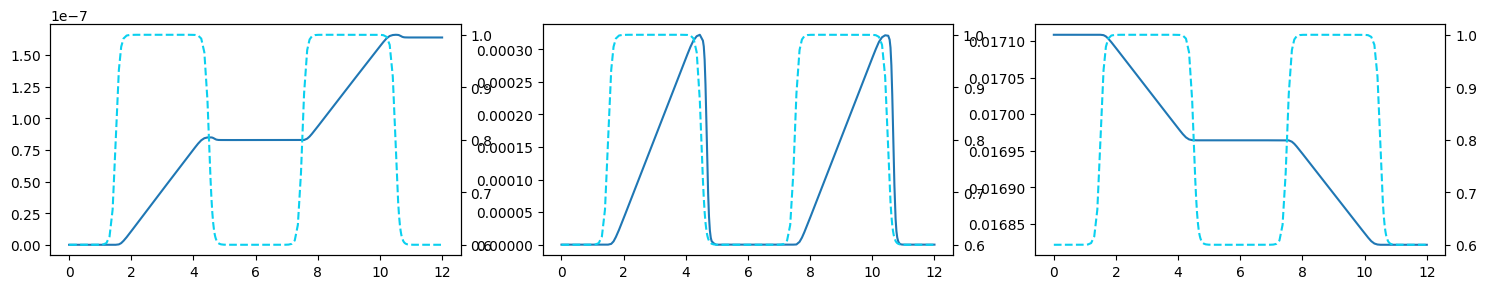

In [10]:
model = ccl()
model.Ucell = ucell_sw
x_init = [0] + [0]*len(r_m) + model.prd0.tolist()
sol = solve_ivp(fun=model.dxdt, y0 = x_init, t_span=(0, 12),max_step=1e-1, method='BDF')
fig, ax = plt.subplots(nrows=1,ncols=3,figsize=(18,3))
ax[0].plot(sol.t, sol.y[0,:])
ax_twin = ax[0].twinx()
ax_twin.plot(sol.t, [ucell_sw(t) for t in sol.t], color = '#0AD0EF', linestyle = '--')
ax[1].plot(sol.t, sol.y[35,:])
ax_twin = ax[1].twinx()
ax_twin.plot(sol.t, [ucell_sw(t) for t in sol.t], color = '#0AD0EF', linestyle = '--')
ax[2].plot(sol.t, sol.y[-15,:])
ax_twin = ax[2].twinx()
ax_twin.plot(sol.t, [ucell_sw(t) for t in sol.t], color = '#0AD0EF', linestyle = '--')


## Case study: Automatic calibration

The automatic calibration applies the experiment data from H. A. Baroody and E. Kjeang, J. Electrochem. Soc., vol. 168, no. 4, p. 044524, Apr. 2021. The search region can be 

narrow down according to prior knowledge about the Pt loading on the well-knowed stack.

It's suggested that to select a parallel execution for the optimizer to reduce the computation time.

The cell below can be copied to an individual Python file for execution

In [15]:
import optuna

def objective(trial):
        # Defining the search region
        krdp_trial = trial.suggest_float("krdp",1e-13,  1e-7, log=True)
        k1_trial = trial.suggest_float("k1", 1e-17, 1e-11, log=True)
        k2_trial = trial.suggest_float("k2", 1e-17, 1e-11, log=True)
        k3_trial = trial.suggest_float("k3", 1e-17, 1e-13, log=True)
        k4_ref_trial = trial.suggest_float("k4_ref", 1e-24, 1e-18, log=True)

        # Per-trial model: optuna with n_jobs > 1 runs trials in parallel
        # threads, so the model object must NOT be shared across trials --
        # otherwise mutating model.parameters causes data races.
        model = ccl()
        model.parameters["krdp"] = krdp_trial
        model.parameters["k1"] = k1_trial
        model.parameters["k2"] = k2_trial
        model.parameters["k3"] = k3_trial
        model.parameters["k4_ref"] = k4_ref_trial

        # Initial state for cycle 0
        x = [0] + [0]*len(r_m) + model.prd0.tolist()

        sol_hist = []
        for i_cycle in range(7):
                sol = solve_ivp(fun=model.dxdt, y0=x, t_span=(0, 5000*6), method="BDF")
                sol_hist.append(sol)
                # Carry the final state of this cycle into the next one;
                # otherwise every cycle starts fresh and sim_data is just
                # seven copies of the cycle-0 ECSA.
                x = sol.y[:, -1]

        sim_data = [1] + [
                (trapezoid(y=(r_m ** 2) * sol_hist[i_sol+1].y[-len(r_m):, -1], x=r_m))
                / (trapezoid(y=(r_m ** 2) * model.prd0, x=r_m))
                for i_sol in range(len(sol_hist) - 1)
        ]

        return  np.sum((np.array(exp_data) - np.array(sim_data)) ** 2)


The execution time of each simulation: around 2 minutes

In [ ]:
from optuna.pruners import MedianPruner

# Each trial runs 7 sequential 30-000 s ODE integrations -- expect a few
# minutes of wall time per trial. Pick a budget you can afford. The
# objective above creates its own ccl() per trial, so n_jobs > 1 is safe.
study = optuna.create_study(direction="minimize", pruner=MedianPruner())
study.optimize(objective, n_trials=1000, timeout=3600*8, n_jobs=4)

print("Best parameters:", study.best_params)
print("Best objective:", study.best_value)


[I 2026-08-04 09:30:54,792] A new study created in memory with name: no-name-b1c740af-978c-4be2-a6fe-f0631ee2a610
[I 2026-08-04 09:37:00,512] Trial 2 finished with value: 2.194825 and parameters: {'krdp': 2.181806849177821e-11, 'k1': 3.464141495324264e-12, 'k2': 1.5194612394245452e-13, 'k3': 6.668959517832572e-16, 'k4_ref': 8.943720594110403e-20}. Best is trial 2 with value: 2.194825.
[I 2026-08-04 09:43:19,336] Trial 4 finished with value: 2.194825 and parameters: {'krdp': 2.376344872226038e-13, 'k1': 4.6658608891580146e-17, 'k2': 7.053868795304732e-16, 'k3': 7.084185481907357e-15, 'k4_ref': 1.2599628596257984e-19}. Best is trial 2 with value: 2.194825.
[I 2026-08-04 09:57:05,828] Trial 1 finished with value: 2.194825 and parameters: {'krdp': 1.7768224012576372e-13, 'k1': 3.7567614616811924e-15, 'k2': 2.117480803600408e-12, 'k3': 7.084751389014067e-14, 'k4_ref': 5.341888816110432e-19}. Best is trial 2 with value: 2.194825.
[I 2026-08-04 10:03:22,273] Trial 6 finished with value: 2.194

Visualizing the calibration result

MSE = 0.0220


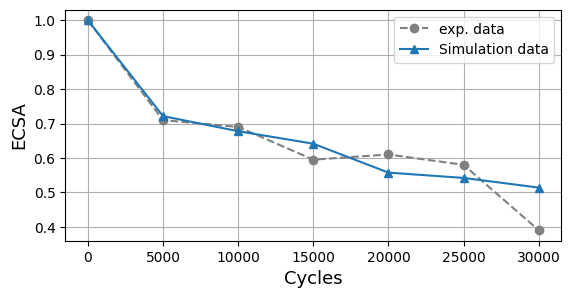

In [ ]:
model = ccl()
for key, value in study.best_params.items():
    model.parameters[key] = value
sol_hist = []
x = [0] + [0]*len(r_m) + model.prd0.tolist()
for i_cycle in range(7):
        sol = solve_ivp(fun=model.dxdt, y0=x, t_span=(0, 5000*6), method="BDF")
        sol_hist.append(sol)
        x = sol.y[:, -1]
sim_data = [1]+[(trapezoid(y=(r_m ** 2) * sol_hist[i_sol+1].y[-len(r_m):,-1], x=r_m))/(trapezoid(y=(r_m ** 2) * model.prd0, x=r_m)) for i_sol in range(len(sol_hist)-1)]
plt.figure(figsize=(6.4,3))
plt.plot([x*5000 for x in range(7)], exp_data, linestyle='--', marker='o', label = "exp. data", color = "grey")
plt.plot([x*5000 for x in range(7)], sim_data, label = "Simulation data", marker = "^")
plt.legend()
plt.xlabel("Cycles",fontsize=13)
plt.ylabel("ECSA",fontsize=13)
plt.grid()

print(f"MSE = {np.sum((np.array(exp_data) - np.array(sim_data)) ** 2):.4f}")

In [ ]:
model.parameters

{'krdp': 1.7695747310540784e-11,
 'k1': 1.7350974368394175e-17,
 'k1_ref': 1e-18,
 'k2': 6.334637862479844e-15,
 'k2_ref': 1e-13,
 'k3': 1.1299039177701413e-14,
 'k4': 0,
 'k5': 0,
 'k4_ref': 1.3160740883282697e-23}